# Complexity vs Risk - Camera-Ready Figure

This notebook builds the final publication figure (dual-panel) for the Complexity vs Risk result.

- **Panel A:** jittered scatter + LOWESS trend + Spearman summary.
- **Panel B:** boxplot + raw points across complexity tertiles.

Exports: PNG, SVG, PDF.

## 1) Imports and Style

In [54]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})


## 2) Configuration

In [55]:
PROJECT_ROOT = Path.cwd()

CANDIDATE_COMPLEXITY_DIRS = [
    PROJECT_ROOT / "complexity",
    PROJECT_ROOT / "Version 2" / "complexity",
    PROJECT_ROOT.parent / "Version 2" / "complexity",
]

CANDIDATE_SENSITIVITY_FILES = [
    PROJECT_ROOT / "sensitivity" / "base_with_risk_score_and_perturbations.csv",
    PROJECT_ROOT / "Version 2" / "sensitivity" / "base_with_risk_score_and_perturbations.csv",
    PROJECT_ROOT.parent / "Version 2" / "sensitivity" / "base_with_risk_score_and_perturbations.csv",
]

COMPLEXITY_DIR = next((p.resolve() for p in CANDIDATE_COMPLEXITY_DIRS if p.exists()), CANDIDATE_COMPLEXITY_DIRS[0].resolve())
SENSITIVITY_FILE = next((p.resolve() for p in CANDIDATE_SENSITIVITY_FILES if p.exists()), CANDIDATE_SENSITIVITY_FILES[0].resolve())

OUTPUT_DIR = COMPLEXITY_DIR.parent / "paper_figures" / "complexity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ACTIVE_COMPLEXITY_FILES = [
    "boxplot_data__complexity_active__Relevance.csv",
    "boxplot_data__complexity_active__Interpretability.csv",
    "boxplot_data__complexity_active__Completeness.csv",
    "boxplot_data__complexity_active__Differential_Regime.csv",
    "boxplot_data__complexity_active__Discretionality.csv",
]

DROP_MISSING_COMPLEXITY = True

FIGSIZE = (7.0, 3.6)  # two-column friendly
WIDTH_RATIOS = [1.65, 1.0]

POINT_COLOR = "#555555"
POINT_SIZE_A = 13
POINT_ALPHA_A = 0.36
Y_JITTER = 0.08
TREND_COLOR = "#028A0F"
TREND_WIDTH = 2.0

MEDIAN_LINE_COLOR = "#3A3A3A"
MEDIAN_LINE_WIDTH = 1.1

BOX_EDGE = "#2F2F2F"
BOX_MEDIAN = "#1F1F1F"

EXPORT_STEM = "paper_complexity_risk_camera_ready"
RNG_SEED = 42

print("COMPLEXITY_DIR:", COMPLEXITY_DIR)
print("SENSITIVITY_FILE:", SENSITIVITY_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)

COMPLEXITY_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\complexity
SENSITIVITY_FILE: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\sensitivity\base_with_risk_score_and_perturbations.csv
OUTPUT_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity


## 3) Data Preparation

In [56]:
def load_complexity_index_table() -> pd.DataFrame:
    parts = []
    for name in ACTIVE_COMPLEXITY_FILES:
        path = COMPLEXITY_DIR / name
        if not path.exists():
            raise FileNotFoundError(f"Missing complexity file: {path}")
        d = pd.read_csv(path)[["Law", "Article", "complexity_index"]].copy()
        parts.append(d)

    out = pd.concat(parts, ignore_index=True).drop_duplicates(["Law", "Article"])
    out["Law_k"] = out["Law"].astype(str).str.strip()
    out["Article_k"] = out["Article"].astype(str).str.strip()
    return out[["Law_k", "Article_k", "complexity_index"]]


def load_risk_table() -> pd.DataFrame:
    df = pd.read_csv(SENSITIVITY_FILE).copy()
    required = {"Law", "Article", "Risk Score"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Sensitivity file missing columns: {sorted(missing)}")

    df["Law_k"] = df["Law"].astype(str).str.strip()
    df["Article_k"] = df["Article"].astype(str).str.strip()
    return df


def build_plot_dataframe() -> pd.DataFrame:
    risk_df = load_risk_table()
    cx_df = load_complexity_index_table()

    df = risk_df.merge(cx_df, on=["Law_k", "Article_k"], how="left")
    df["complexity_missing"] = df["complexity_index"].isna()

    if DROP_MISSING_COMPLEXITY:
        df = df.dropna(subset=["complexity_index"]).copy()

    # Tertiles for panel B
    labels = ["Low", "Medium", "High"]
    df["complexity_group"] = pd.qcut(df["complexity_index"], q=3, labels=labels)
    return df


plot_df = build_plot_dataframe()
cx = float(plot_df["complexity_index"].median())
ry = float(plot_df["Risk Score"].median())
rho, pval = spearmanr(plot_df["complexity_index"], plot_df["Risk Score"])

group_counts = plot_df["complexity_group"].value_counts().reindex(["Low", "Medium", "High"])

print(f"Rows used: {len(plot_df)}")
print(f"Complexity median: {cx:.4f}")
print(f"Risk median: {ry:.4f}")
print(f"Spearman rho: {rho:.3f} (p={pval:.3g})")
group_counts

Rows used: 148
Complexity median: 0.1098
Risk median: 3.0000
Spearman rho: 0.340 (p=2.37e-05)


complexity_group
Low       50
Medium    48
High      50
Name: count, dtype: int64

## 4) Build Final Figure (Option 1)

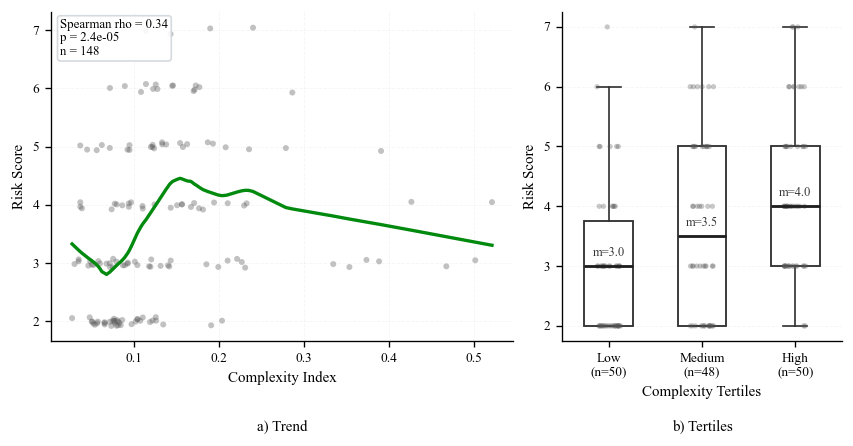

Saved final figure:
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_risk_camera_ready.png
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_risk_camera_ready.svg
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_risk_camera_ready.pdf


In [57]:
rng = np.random.default_rng(RNG_SEED)

fig = plt.figure(figsize=FIGSIZE, constrained_layout=True)
gs = GridSpec(1, 2, figure=fig, width_ratios=WIDTH_RATIOS)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

# ---------------------------
# Panel A: scatter + lowess
# ---------------------------
x = plot_df["complexity_index"].to_numpy()
y = plot_df["Risk Score"].to_numpy()
y_j = y + rng.uniform(-Y_JITTER, Y_JITTER, size=len(y))

ax_a.scatter(
    x, y_j,
    s=POINT_SIZE_A,
    c=POINT_COLOR,
    alpha=POINT_ALPHA_A,
    edgecolors="none",
)

lo = lowess(endog=y, exog=x, frac=0.45, return_sorted=True)
ax_a.plot(lo[:, 0], lo[:, 1], color=TREND_COLOR, linewidth=TREND_WIDTH, zorder=3)


ax_a.set_xlabel("Complexity Index")
ax_a.set_ylabel("Risk Score")
ax_a.text(0.5, -0.24, "a) Trend", transform=ax_a.transAxes, ha="center", va="top", fontsize=9)
ax_a.grid(alpha=0.12, linestyle="--", linewidth=0.55)

ax_a.text(
    0.02, 0.98,
    f"Spearman rho = {rho:.2f}\np = {pval:.2g}\nn = {len(plot_df)}",
    transform=ax_a.transAxes,
    ha="left", va="top", fontsize=7.7,
    bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="#D1D6DB", alpha=0.9),
)


# -----------------------------------
# Panel B: boxplot + jittered points
# -----------------------------------
order = ["Low", "Medium", "High"]
groups = [plot_df.loc[plot_df["complexity_group"] == g, "Risk Score"].to_numpy() for g in order]

bp = ax_b.boxplot(
    groups,
    positions=np.arange(len(order)),
    widths=0.52,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="white", edgecolor=BOX_EDGE, linewidth=1.1),
    medianprops=dict(color=BOX_MEDIAN, linewidth=1.7),
    whiskerprops=dict(color=BOX_EDGE, linewidth=1.0),
    capprops=dict(color=BOX_EDGE, linewidth=1.0),
)

for i, g in enumerate(order):
    vals = plot_df.loc[plot_df["complexity_group"] == g, "Risk Score"].to_numpy()
    xj = i + rng.uniform(-0.13, 0.13, size=len(vals))
    ax_b.scatter(xj, vals, s=10, color=POINT_COLOR, alpha=0.32, edgecolors="none", zorder=2)

    med = float(np.median(vals)) if len(vals) else np.nan
    if np.isfinite(med):
        ax_b.text(i, med + 0.12, f"m={med:.1f}", ha="center", va="bottom", fontsize=7.5, color="#333333")

xticklabels = [f"{g}\n(n={int(group_counts[g])})" for g in order]
ax_b.set_xticks(np.arange(len(order)))
ax_b.set_xticklabels(xticklabels)
ax_b.set_xlabel("Complexity Tertiles")
ax_b.set_ylabel("Risk Score")
ax_b.text(0.5, -0.24, "b) Tertiles", transform=ax_b.transAxes, ha="center", va="top", fontsize=9)
ax_b.grid(axis="y", alpha=0.12, linestyle="--", linewidth=0.55)

for ax in [ax_a, ax_b]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

out_png = OUTPUT_DIR / f"{EXPORT_STEM}.png"
out_svg = OUTPUT_DIR / f"{EXPORT_STEM}.svg"
out_pdf = OUTPUT_DIR / f"{EXPORT_STEM}.pdf"

fig.savefig(out_png, dpi=400, bbox_inches="tight")
fig.savefig(out_svg, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved final figure:")
print("-", out_png)
print("-", out_svg)
print("-", out_pdf)



## 5) Export Individual Panels (PDF, no bottom labels)


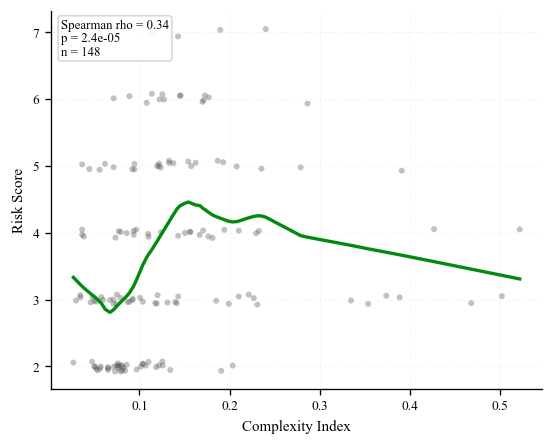

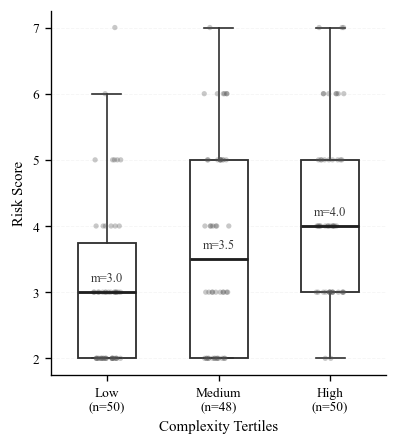

Saved separate panel PDFs:
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_risk_panel_a_trend.pdf
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_risk_panel_b_tertiles.pdf


In [58]:
rng = np.random.default_rng(RNG_SEED)

# ---------------------------
# Panel A export (PDF only)
# ---------------------------
fig_a, ax_a = plt.subplots(figsize=(4.5, 3.6), constrained_layout=True)

x = plot_df["complexity_index"].to_numpy()
y = plot_df["Risk Score"].to_numpy()
y_j = y + rng.uniform(-Y_JITTER, Y_JITTER, size=len(y))

ax_a.scatter(
    x, y_j,
    s=POINT_SIZE_A,
    c=POINT_COLOR,
    alpha=POINT_ALPHA_A,
    edgecolors="none",
)

lo = lowess(endog=y, exog=x, frac=0.45, return_sorted=True)
ax_a.plot(lo[:, 0], lo[:, 1], color=TREND_COLOR, linewidth=TREND_WIDTH, zorder=3)


ax_a.set_xlabel("Complexity Index")
ax_a.set_ylabel("Risk Score")
ax_a.grid(alpha=0.12, linestyle="--", linewidth=0.55)

ax_a.text(
    0.02, 0.98,
    f"Spearman rho = {rho:.2f}\np = {pval:.2g}\nn = {len(plot_df)}",
    transform=ax_a.transAxes,
    ha="left", va="top", fontsize=7.7,
    bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="#D1D6DB", alpha=0.9),
)

ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)

panel_a_pdf = OUTPUT_DIR / "paper_complexity_risk_panel_a_trend.pdf"
fig_a.savefig(panel_a_pdf, bbox_inches="tight")
plt.show()
plt.close(fig_a)

# ---------------------------
# Panel B export (PDF only)
# ---------------------------
rng = np.random.default_rng(RNG_SEED)
fig_b, ax_b = plt.subplots(figsize=(3.2, 3.6), constrained_layout=True)

order = ["Low", "Medium", "High"]
groups = [plot_df.loc[plot_df["complexity_group"] == g, "Risk Score"].to_numpy() for g in order]

ax_b.boxplot(
    groups,
    positions=np.arange(len(order)),
    widths=0.52,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="white", edgecolor=BOX_EDGE, linewidth=1.1),
    medianprops=dict(color=BOX_MEDIAN, linewidth=1.7),
    whiskerprops=dict(color=BOX_EDGE, linewidth=1.0),
    capprops=dict(color=BOX_EDGE, linewidth=1.0),
)

for i, g in enumerate(order):
    vals = plot_df.loc[plot_df["complexity_group"] == g, "Risk Score"].to_numpy()
    xj = i + rng.uniform(-0.13, 0.13, size=len(vals))
    ax_b.scatter(xj, vals, s=10, color=POINT_COLOR, alpha=0.32, edgecolors="none", zorder=2)

    med = float(np.median(vals)) if len(vals) else np.nan
    if np.isfinite(med):
        ax_b.text(i, med + 0.12, f"m={med:.1f}", ha="center", va="bottom", fontsize=7.5, color="#333333")

xticklabels = [f"{g}\n(n={int(group_counts[g])})" for g in order]
ax_b.set_xticks(np.arange(len(order)))
ax_b.set_xticklabels(xticklabels)
ax_b.set_xlabel("Complexity Tertiles")
ax_b.set_ylabel("Risk Score")
ax_b.grid(axis="y", alpha=0.12, linestyle="--", linewidth=0.55)

ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)

panel_b_pdf = OUTPUT_DIR / "paper_complexity_risk_panel_b_tertiles.pdf"
fig_b.savefig(panel_b_pdf, bbox_inches="tight")
plt.show()
plt.close(fig_b)

print("Saved separate panel PDFs:")
print("-", panel_a_pdf)
print("-", panel_b_pdf)


## 6) Optional Option 2 (Single-Panel Cleaner Hexbin)

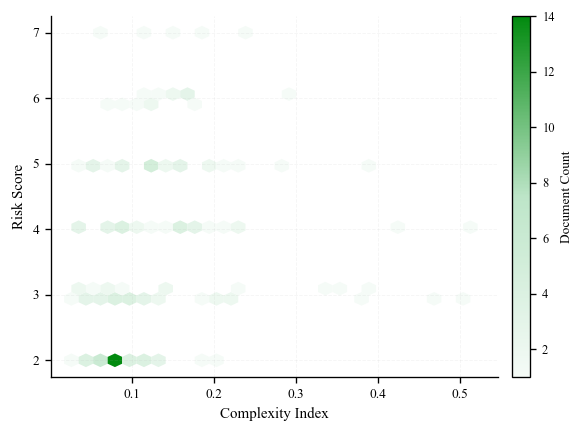

Saved optional figure:
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_risk_camera_ready__option2.png
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_risk_camera_ready__option2.svg
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_risk_camera_ready__option2.pdf


In [59]:
fig, ax = plt.subplots(figsize=(5.2, 3.9))

hb = ax.hexbin(
    plot_df["complexity_index"],
    plot_df["Risk Score"],
    gridsize=28,
    cmap=LinearSegmentedColormap.from_list("opt2", ["#F5FBF7", "#BDE5C8", TREND_COLOR]),
    mincnt=1,
    linewidths=0.0,
)

ax.set_xlabel("Complexity Index")
ax.set_ylabel("Risk Score")
ax.grid(alpha=0.12, linestyle="--", linewidth=0.55)

cbar = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label("Document Count", fontsize=8)
cbar.ax.tick_params(labelsize=7.5)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

opt2_png = OUTPUT_DIR / f"{EXPORT_STEM}__option2.png"
opt2_svg = OUTPUT_DIR / f"{EXPORT_STEM}__option2.svg"
opt2_pdf = OUTPUT_DIR / f"{EXPORT_STEM}__option2.pdf"

fig.savefig(opt2_png, dpi=400, bbox_inches="tight")
fig.savefig(opt2_svg, bbox_inches="tight")
fig.savefig(opt2_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved optional figure:")
print("-", opt2_png)
print("-", opt2_svg)
print("-", opt2_pdf)

## 7) Reproducibility Metadata

In [60]:
meta = pd.DataFrame([{
    "complexity_dir": str(COMPLEXITY_DIR),
    "sensitivity_file": str(SENSITIVITY_FILE),
    "rows_total_risk": len(load_risk_table()),
    "rows_used": len(plot_df),
    "rows_missing_complexity": int(load_risk_table().merge(load_complexity_index_table(), on=['Law_k','Article_k'], how='left')['complexity_index'].isna().sum()),
    "drop_missing_complexity": DROP_MISSING_COMPLEXITY,
    "complexity_median": cx,
    "risk_median": ry,
    "spearman_rho": rho,
    "spearman_p": pval,
    "export_stem": EXPORT_STEM,
}])

meta_path = OUTPUT_DIR / 'paper_complexity_camera_ready_metadata.csv'
meta.to_csv(meta_path, index=False)
print('Saved metadata:', meta_path)
meta

Saved metadata: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_camera_ready_metadata.csv


,complexity_dir,sensitivity_file,rows_total_risk,rows_used,rows_missing_complexity,drop_missing_complexity,complexity_median,risk_median,spearman_rho,spearman_p,export_stem
0,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,169,148,21,True,0.109842,3.0,0.339896,0.000024,paper_complexity_risk_camera_ready
